# Regression and Robustness

In [63]:
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os


In [2]:
df = pd.read_parquet("../data/processed/merged_ems_acs_with_severity.parquet")
df.head

<bound method NDFrame.head of        cad_incident_id   incident_datetime initial_call_type  \
0            240010001 2024-01-01 00:00:03            INJURY   
1            240010002 2024-01-01 00:00:14              CARD   
2            240010004 2024-01-01 00:00:45            RESPIR   
3            240010005 2024-01-01 00:00:55            BURNMI   
4            240010006 2024-01-01 00:01:12              EDPC   
...                ...                 ...               ...   
363478       240915149 2024-03-31 23:54:42              EDPC   
363479       240915150 2024-03-31 23:54:55              SICK   
363480       240915152 2024-03-31 23:55:32              EDPC   
363481       240915154 2024-03-31 23:56:38              EDPC   
363482       240915157 2024-03-31 23:57:18            MVAINJ   

       initial_severity_level_code final_call_type final_severity_level_code  \
0                                5          INJURY                         5   
1                                3       

In [54]:
df["severity_tier_numeric"].unique()

array([3, 2, 1], dtype=int64)

In [7]:
df["hour"] = df["incident_datetime"].dt.hour
df["day_of_week"] = df["incident_datetime"].dt.dayofweek


## Control Model

In [55]:
control_model = smf.ols(
    "incident_response_seconds_qy ~ C(hour) + C(day_of_week) + C(severity_tier_numeric) + C(borough)",
    data=df
).fit()

In [56]:
control_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     incident_response_seconds_qy   R-squared:                       0.120
Model:                                      OLS   Adj. R-squared:                  0.120
Method:                           Least Squares   F-statistic:                     1418.
Date:                          Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                                  12:03:37   Log-Likelihood:            -2.8634e+06
No. Observations:                        363483   AIC:                         5.727e+06
Df Residuals:                            363447   BIC:                         5.727e+06
Df Model:                                    35                                         
Covariance Type:                      nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                399.2046      6.722     59.385      0.000     386.029     412.380
C(hour)[T.1]                              17.1794      8.162      2.105      0.035       1.182      33.177
C(hour)[T.2]                              20.1501      8.517      2.366      0.018       3.458      36.842
C(hour)[T.3]                              61.1158      8.783      6.958      0.000      43.901      78.331
C(hour)[T.4]                              61.0062      8.990      6.786      0.000      43.387      78.626
C(hour)[T.5]                              80.2434      9.126      8.792      0.000      62.356      98.131
C(hour)[T.6]                             151.7101      8.827     17.188      0.000     134.410     169.010
C(hour)[T.7]                             128.4967      8.297     15.487      0.000     112.235     144.759
C(hour)[T.8]                             138.2589      7.722     17.905      0.000     123.124     153.394
C(hour)[T.9]                             124.7839      7.383     16.901      0.000     110.313     139.255
C(hour)[T.10]                            110.7840      7.297     15.181      0.000      96.481     125.087
C(hour)[T.11]                            150.8011      7.258     20.777      0.000     136.575     165.027
C(hour)[T.12]                            173.4313      7.248     23.927      0.000     159.225     187.638
C(hour)[T.13]                            204.3775      7.259     28.156      0.000     190.150     218.605
C(hour)[T.14]                            258.5651      7.226     35.785      0.000     244.403     272.727
C(hour)[T.15]                            341.2819      7.239     47.147      0.000     327.094     355.470
C(hour)[T.16]                            356.0016      7.278     48.914      0.000     341.737     370.266
C(hour)[T.17]                            401.3826      7.293     55.038      0.000     387.089     415.676
C(hour)[T.18]                            411.5484      7.306     56.332      0.000     397.229     425.868
C(hour)[T.19]                            223.9714      7.317     30.611      0.000     209.631     238.312
C(hour)[T.20]                            101.2549      7.375     13.729      0.000      86.800     115.710
C(hour)[T.21]                             42.0812      7.458      5.642      0.000      27.463      56.700
C(hour)[T.22]                             20.6610      7.577      2.727      0.006       5.810      35.512
C(hour)[T.23]                              6.3227      7.795      0.811      0.417      -8.956      21.601
C(day_of_week)[T.1]                      -62.7436      3.931    -15.962      0.000  

In [21]:
df["high_black_zip"]

0         0
1         1
2         0
3         1
4         0
         ..
363478    0
363479    1
363480    0
363481    1
363482    0
Name: high_black_zip, Length: 363483, dtype: int64

## More Models

Model 1: controls + high_black_zip
Model 2: controls + median_income
Model 3: controls + high_black_zip + median_income + pct_white + pct_black + pct_hispanic

In [22]:
model1 = smf.ols(
    "incident_response_seconds_qy ~ C(hour) + C(day_of_week) + C(severity_tier_numeric) + C(borough) + C(high_black_zip)",
    data=df
).fit()

In [23]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     incident_response_seconds_qy   R-squared:                       0.123
Model:                                      OLS   Adj. R-squared:                  0.123
Method:                           Least Squares   F-statistic:                     1418.
Date:                          Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                                  16:41:59   Log-Likelihood:            -2.8627e+06
No. Observations:                        363483   AIC:                         5.726e+06
Df Residuals:                            363446   BIC:                         5.726e+06
Df Model:                                    36                                         
Covariance Type:                      nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                326.0518      7.021     46.437      0.000     312.290     339.814
C(hour)[T.1]                              18.0079      8.148      2.210      0.027       2.038      33.978
C(hour)[T.2]                              20.2651      8.502      2.384      0.017       3.601      36.929
C(hour)[T.3]                              61.3499      8.768      6.997      0.000      44.165      78.535
C(hour)[T.4]                              61.9424      8.974      6.902      0.000      44.353      79.532
C(hour)[T.5]                              79.2316      9.111      8.697      0.000      61.375      97.088
C(hour)[T.6]                             151.4155      8.812     17.184      0.000     134.145     168.686
C(hour)[T.7]                             128.0163      8.283     15.456      0.000     111.782     144.250
C(hour)[T.8]                             137.6896      7.709     17.862      0.000     122.581     152.798
C(hour)[T.9]                             124.5854      7.370     16.903      0.000     110.140     139.031
C(hour)[T.10]                            110.9630      7.285     15.232      0.000      96.685     125.241
C(hour)[T.11]                            151.4379      7.246     20.900      0.000     137.237     165.639
C(hour)[T.12]                            174.2541      7.236     24.081      0.000     160.072     188.437
C(hour)[T.13]                            205.2908      7.246     28.330      0.000     191.088     219.493
C(hour)[T.14]                            259.3632      7.213     35.957      0.000     245.226     273.501
C(hour)[T.15]                            341.7463      7.226     47.292      0.000     327.583     355.910
C(hour)[T.16]                            356.8213      7.266     49.111      0.000     342.581     371.062
C(hour)[T.17]                            402.1646      7.280     55.240      0.000     387.895     416.434
C(hour)[T.18]                            411.8889      7.293     56.476      0.000     397.594     426.183
C(hour)[T.19]                            223.9956      7.304     30.667      0.000     209.680     238.312
C(hour)[T.20]                            101.7624      7.362     13.822      0.000      87.332     116.192
C(hour)[T.21]                             42.1024      7.446      5.655      0.000      27.509      56.696
C(hour)[T.22]                             20.9308      7.564      2.767      0.006       6.105      35.756
C(hour)[T.23]                              6.2282      7.782      0.800      0.424      -9.024      21.481
C(day_of_week)[T.1]                      -62.5785      3.924    -15.947      0.000  

We find that high_black_zip has a p-value of >0.000 which indicates high_black_zip is statistically significant for emergency response time. The coeffient of high_black_zip is 84.5193 which indicates that response times get longer when visiting zip codes with black majorities. We also find that the R^2 value increases from 0.120 in the controlled model to 0.123 in this new model indicating a slightly better performance.

In [24]:
df["median_income"]

0          82655.0
1          41145.0
2          77209.0
3          56298.0
4         110123.0
            ...   
363478     41550.0
363479    101416.0
363480    113335.0
363481     73118.0
363482         NaN
Name: median_income, Length: 363483, dtype: float64

In [25]:
model2 = smf.ols(
    "incident_response_seconds_qy ~ C(hour) + C(day_of_week) + C(severity_tier_numeric) + C(borough) + C(high_black_zip) + median_income",
    data=df
).fit()

In [26]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     incident_response_seconds_qy   R-squared:                       0.125
Model:                                      OLS   Adj. R-squared:                  0.125
Method:                           Least Squares   F-statistic:                     1387.
Date:                          Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                                  16:48:20   Log-Likelihood:            -2.8280e+06
No. Observations:                        359114   AIC:                         5.656e+06
Df Residuals:                            359076   BIC:                         5.657e+06
Df Model:                                    37                                         
Covariance Type:                      nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                350.4774      7.530     46.545      0.000     335.719     365.236
C(hour)[T.1]                              19.6591      8.185      2.402      0.016       3.617      35.701
C(hour)[T.2]                              22.3312      8.534      2.617      0.009       5.604      39.058
C(hour)[T.3]                              62.8511      8.810      7.134      0.000      45.584      80.118
C(hour)[T.4]                              62.2131      9.024      6.894      0.000      44.527      79.899
C(hour)[T.5]                              79.1095      9.160      8.636      0.000      61.155      97.064
C(hour)[T.6]                             150.9806      8.880     17.003      0.000     133.576     168.385
C(hour)[T.7]                             128.5646      8.337     15.421      0.000     112.224     144.905
C(hour)[T.8]                             138.4016      7.750     17.859      0.000     123.212     153.591
C(hour)[T.9]                             126.4588      7.407     17.072      0.000     111.941     140.977
C(hour)[T.10]                            112.7691      7.318     15.410      0.000      98.427     127.112
C(hour)[T.11]                            153.9448      7.280     21.146      0.000     139.676     168.213
C(hour)[T.12]                            176.2407      7.272     24.235      0.000     161.987     190.494
C(hour)[T.13]                            207.0825      7.282     28.436      0.000     192.809     221.356
C(hour)[T.14]                            262.2903      7.252     36.166      0.000     248.076     276.505
C(hour)[T.15]                            344.4543      7.266     47.407      0.000     330.213     358.695
C(hour)[T.16]                            359.4432      7.307     49.195      0.000     345.123     373.764
C(hour)[T.17]                            405.1898      7.321     55.349      0.000     390.842     419.538
C(hour)[T.18]                            415.2740      7.336     56.608      0.000     400.896     429.652
C(hour)[T.19]                            226.5430      7.343     30.853      0.000     212.152     240.934
C(hour)[T.20]                            102.7758      7.400     13.888      0.000      88.271     117.280
C(hour)[T.21]                             42.7139      7.486      5.706      0.000      28.042      57.386
C(hour)[T.22]                             22.1845      7.608      2.916      0.004       7.274      37.095
C(hour)[T.23]                              7.5776      7.821      0.969      0.333      -7.752      22.907
C(day_of_week)[T.1]                      -61.7023      3.945    -15.642      0.000  

When adding median_income to the model we find that median_income has a p-value of >0.000 which indicates that median_income is statistically significant. Unlike high_black_zip, however, the cooefficient of median_income is -0.0004 which indicates that as median_income increases, the emergency dispatch time decreases.

Interestingly, when we added median_income to the model, the coefficient for high_black_zip decreased to 74.9695.

Overall the new model has a R^2 of 0.125.

In [4]:
df["pct_white"]

0         0.270227
1         0.145921
2         0.326821
3         0.172638
4         0.886989
            ...   
363478    0.112194
363479    0.076078
363480    0.625590
363481    0.041683
363482         NaN
Name: pct_white, Length: 363483, dtype: float64

In [14]:
model3 = smf.ols(
    "incident_response_seconds_qy ~ C(hour) + C(day_of_week) + C(severity_tier_numeric) + C(borough) + C(high_black_zip) + median_income + pct_white + pct_black + pct_hispanic",
    data=df
).fit()

In [15]:
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     incident_response_seconds_qy   R-squared:                       0.127
Model:                                      OLS   Adj. R-squared:                  0.127
Method:                           Least Squares   F-statistic:                     1301.
Date:                          Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                                  10:11:51   Log-Likelihood:            -2.8277e+06
No. Observations:                        359114   AIC:                         5.656e+06
Df Residuals:                            359073   BIC:                         5.656e+06
Df Model:                                    40                                         
Covariance Type:                      nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                206.1636     11.960     17.237      0.000     182.722     229.606
C(hour)[T.1]                              19.5293      8.178      2.388      0.017       3.501      35.557
C(hour)[T.2]                              21.7618      8.527      2.552      0.011       5.049      38.474
C(hour)[T.3]                              62.7938      8.802      7.134      0.000      45.542      80.046
C(hour)[T.4]                              62.1406      9.016      6.893      0.000      44.470      79.811
C(hour)[T.5]                              79.3588      9.152      8.671      0.000      61.421      97.297
C(hour)[T.6]                             151.1481      8.872     17.036      0.000     133.759     168.537
C(hour)[T.7]                             129.6382      8.330     15.563      0.000     113.312     145.964
C(hour)[T.8]                             139.8886      7.743     18.066      0.000     124.712     155.065
C(hour)[T.9]                             127.6930      7.401     17.254      0.000     113.187     142.199
C(hour)[T.10]                            113.9654      7.311     15.587      0.000      99.635     128.296
C(hour)[T.11]                            155.0474      7.274     21.316      0.000     140.791     169.304
C(hour)[T.12]                            177.3983      7.266     24.415      0.000     163.157     191.639
C(hour)[T.13]                            208.2794      7.276     28.625      0.000     194.019     222.540
C(hour)[T.14]                            263.4821      7.246     36.362      0.000     249.280     277.684
C(hour)[T.15]                            345.9508      7.260     47.653      0.000     331.722     360.180
C(hour)[T.16]                            360.5434      7.300     49.388      0.000     346.235     374.852
C(hour)[T.17]                            406.6443      7.314     55.596      0.000     392.308     420.980
C(hour)[T.18]                            416.4802      7.330     56.821      0.000     402.114     430.846
C(hour)[T.19]                            227.8839      7.336     31.062      0.000     213.505     242.263
C(hour)[T.20]                            104.2059      7.394     14.093      0.000      89.714     118.698
C(hour)[T.21]                             43.5155      7.479      5.818      0.000      28.857      58.175
C(hour)[T.22]                             22.8735      7.601      3.009      0.003       7.976      37.771
C(hour)[T.23]                              8.0117      7.814      1.025      0.305      -7.304      23.327
C(day_of_week)[T.1]                      -61.9298      3.941    -15.713      0.000  

After adding the percent of white, black, and hispanicss to the model we find interesting results. The p-values for all 3 variables are > 0.05 which indicates statistical significance. Interestingly, pct_white is the only one of the three with a negative coefficient which indicates that as pct_white increases, the emergency response time decreases. This is the opposite for pct_black and pct_hispanic - as pct_black or pct_hispanic increases, the emergency response time increases. This is a clear form of bias in the model! 

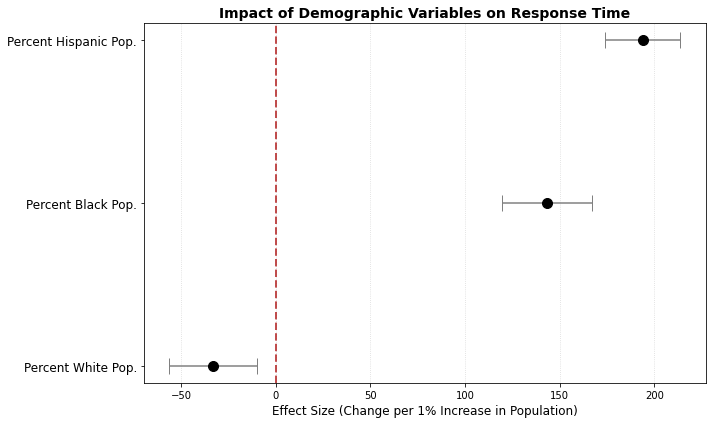

In [71]:

def clean_model_labels(label):

    label = re.sub(r'C\((.*?)\)\[T\..*?\]', r'\1', label)

    label = label.replace('pct_white', 'Percent White Pop.')
    label = label.replace('pct_black', 'Percent Black Pop.')
    label = label.replace('pct_hispanic', 'Percent Hispanic Pop.')

    return label.replace('_', ' ').title()

params = model3.params
conf = model3.conf_int()

plot_df = pd.DataFrame({
    'Variable': params.index,
    'Coefficient': params.values,
    'Lower': conf[0].values,
    'Upper': conf[1].values
})


target_vars = ['pct_white', 'pct_black', 'pct_hispanic']
filtered_df = plot_df[plot_df['Variable'].str.contains('|'.join(target_vars), case=False)].copy()

filtered_df['Clean_Label'] = filtered_df['Variable'].apply(clean_model_labels)


plt.figure(figsize=(10, 6))

filtered_df = filtered_df.sort_values('Coefficient')


y_pos = range(len(filtered_df))

plt.errorbar(filtered_df['Coefficient'], y_pos, 
             xerr=[filtered_df['Coefficient'] - filtered_df['Lower'], 
                   filtered_df['Upper'] - filtered_df['Coefficient']], 
             fmt='o', color='black', ecolor='gray', capsize=8, markersize=10)


plt.axvline(x=0, color='firebrick', linestyle='--', linewidth=2, alpha=0.8)

plt.yticks(y_pos, filtered_df['Clean_Label'], fontsize=12)

plt.xlabel('Effect Size (Change per 1% Increase in Population)', fontsize=12)
plt.title('Impact of Demographic Variables on Response Time', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/figures/demographic_impact_plot.png", 
            dpi=300, 
            facecolor='white', 
            edgecolor='none', 
            transparent=False)
plt.show()

# MAUP Checks

In [29]:
# aggregate to borough

borough_demo = df.groupby("borough").agg({
    "pct_black": "mean",
    "pct_white": "mean",
    "pct_hispanic": "mean",
    "median_income": "mean"
}).reset_index()

threshold = borough_demo["pct_black"].median()

borough_demo["high_black_borough"] = (
    borough_demo["pct_black"] > threshold
).astype(int)


borough_demo = borough_demo.rename(columns={
    "pct_black": "pct_black_borough",
    "pct_white": "pct_white_borough",
    "pct_hispanic": "pct_hispanic_borough",
    "median_income": "median_income_borough"
})

df_borough = df.merge(borough_demo, on="borough", suffixes=("", "_borough"))

In [30]:
df_borough

,cad_incident_id,incident_datetime,initial_call_type,initial_severity_level_code,final_call_type,final_severity_level_code,valid_dispatch_rspns_time_indc,dispatch_response_seconds_qy,valid_incident_rspns_time_indc,incident_response_seconds_qy,...,severity_tier,severity_tier_numeric,high_severity,hour,day_of_week,pct_black_borough,pct_white_borough,pct_hispanic_borough,median_income_borough,high_black_borough
0,240010001,2024-01-01 00:00:03,INJURY,5,INJURY,5,Y,53,Y,393.0,...,Low,3,0,0,0,0.211043,0.281615,0.273871,82447.116937,0
1,240010007,2024-01-01 00:01:16,INJURY,5,INJURY,5,Y,50,Y,457.0,...,Low,3,0,0,0,0.211043,0.281615,0.273871,82447.116937,0
2,240010009,2024-01-01 00:01:47,INJURY,5,INJURY,5,Y,14,Y,674.0,...,Low,3,0,0,0,0.211043,0.281615,0.273871,82447.116937,0
3,240010016,2024-01-01 00:03:55,SICK,6,SICK,6,Y,7,Y,397.0,...,Low,3,0,0,0,0.211043,0.281615,0.273871,82447.116937,0
4,240010017,2024-01-01 00:04:05,ABDPN,5,ABDPN,5,Y,6,Y,752.0,...,Low,3,0,0,0,0.211043,0.281615,0.273871,82447.116937,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363478,240915003,2024-03-31 23:10:53,SICK,6,SICK,6,Y,5,Y,432.0,...,Low,3,0,23,6,0.131040,0.612361,0.209338,92235.838703,0
363479,240915081,2024-03-31 23:32:34,SICK,6,CARDBR,2,Y,6,Y,378.0,...,High,1,1,23,6,0.131040,0.612361,0.209338,92235.838703,0
363480,240915103,2024-03-31 23:38:06,CARDBR,2,CARDBR,2,Y,15,Y,833.0,...,High,1,1,23,6,0.131040,0.612361,0.209338,92235.838703,0
363481,240915133,2024-03-31 23:48:36,ABDPN,5,ABDPN,5,Y,7,Y,339.0,...,Low,3,0,23,6,0.131040,0.612361,0.209338,92235.838703,0


## Testing same models

In [34]:
model1_borough = smf.ols(
    "incident_response_seconds_qy ~ C(hour) + C(day_of_week) + C(severity_tier_numeric) + C(borough) + C(high_black_borough)",
    data=df_borough
).fit()

In [35]:
model1_borough.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     incident_response_seconds_qy   R-squared:                       0.120
Model:                                      OLS   Adj. R-squared:                  0.120
Method:                           Least Squares   F-statistic:                     1378.
Date:                          Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                                  10:38:13   Log-Likelihood:            -2.8634e+06
No. Observations:                        363483   AIC:                         5.727e+06
Df Residuals:                            363446   BIC:                         5.727e+06
Df Model:                                    36                                         
Covariance Type:                      nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                               9.097e+12    1.6e+13      0.567      0.571   -2.24e+13    4.05e+13
C(hour)[T.1]                              17.1998      8.162      2.107      0.035       1.202      33.197
C(hour)[T.2]                              20.1580      8.517      2.367      0.018       3.466      36.850
C(hour)[T.3]                              61.1359      8.783      6.960      0.000      43.921      78.351
C(hour)[T.4]                              61.0057      8.990      6.786      0.000      43.386      78.625
C(hour)[T.5]                              80.2400      9.126      8.792      0.000      62.353      98.127
C(hour)[T.6]                             151.7123      8.827     17.188      0.000     134.412     169.012
C(hour)[T.7]                             128.4830      8.297     15.485      0.000     112.221     144.745
C(hour)[T.8]                             138.2688      7.722     17.906      0.000     123.134     153.404
C(hour)[T.9]                             124.7959      7.383     16.903      0.000     110.325     139.267
C(hour)[T.10]                            110.7659      7.297     15.179      0.000      96.463     125.069
C(hour)[T.11]                            150.7964      7.258     20.776      0.000     136.571     165.022
C(hour)[T.12]                            173.4300      7.248     23.926      0.000     159.223     187.637
C(hour)[T.13]                            204.3885      7.259     28.157      0.000     190.161     218.616
C(hour)[T.14]                            258.5704      7.226     35.786      0.000     244.409     272.732
C(hour)[T.15]                            341.2781      7.239     47.146      0.000     327.090     355.466
C(hour)[T.16]                            355.9975      7.278     48.914      0.000     341.733     370.262
C(hour)[T.17]                            401.3826      7.293     55.038      0.000     387.089     415.676
C(hour)[T.18]                            411.5433      7.306     56.331      0.000     397.224     425.862
C(hour)[T.19]                            223.9562      7.317     30.608      0.000     209.615     238.297
C(hour)[T.20]                            101.2374      7.375     13.727      0.000      86.782     115.692
C(hour)[T.21]                             42.0641      7.459      5.640      0.000      27.446      56.683
C(hour)[T.22]                             20.6463      7.577      2.725      0.006       5.795      35.497
C(hour)[T.23]                              6.3221      7.795      0.811      0.417      -8.957      21.601
C(day_of_week)[T.1]                      -62.7283      3.931    -15.957      0.000  

In [40]:
model2_borough = smf.ols(
    "incident_response_seconds_qy ~ C(hour) + C(day_of_week) + C(severity_tier_numeric) + C(borough) + C(high_black_borough) + median_income_borough",
    data=df_borough
).fit()

In [41]:
model2_borough.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     incident_response_seconds_qy   R-squared:                       0.120
Model:                                      OLS   Adj. R-squared:                  0.120
Method:                           Least Squares   F-statistic:                     1418.
Date:                          Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                                  10:40:50   Log-Likelihood:            -2.8634e+06
No. Observations:                        363483   AIC:                         5.727e+06
Df Residuals:                            363447   BIC:                         5.727e+06
Df Model:                                    35                                         
Covariance Type:                      nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                123.7337      2.303     53.730      0.000     119.220     128.247
C(hour)[T.1]                              17.1794      8.162      2.105      0.035       1.182      33.177
C(hour)[T.2]                              20.1501      8.517      2.366      0.018       3.458      36.842
C(hour)[T.3]                              61.1158      8.783      6.958      0.000      43.901      78.331
C(hour)[T.4]                              61.0062      8.990      6.786      0.000      43.387      78.626
C(hour)[T.5]                              80.2434      9.126      8.792      0.000      62.356      98.131
C(hour)[T.6]                             151.7101      8.827     17.188      0.000     134.410     169.010
C(hour)[T.7]                             128.4967      8.297     15.487      0.000     112.235     144.759
C(hour)[T.8]                             138.2589      7.722     17.905      0.000     123.124     153.394
C(hour)[T.9]                             124.7839      7.383     16.901      0.000     110.313     139.255
C(hour)[T.10]                            110.7840      7.297     15.181      0.000      96.481     125.087
C(hour)[T.11]                            150.8011      7.258     20.777      0.000     136.575     165.027
C(hour)[T.12]                            173.4313      7.248     23.927      0.000     159.225     187.638
C(hour)[T.13]                            204.3775      7.259     28.156      0.000     190.150     218.605
C(hour)[T.14]                            258.5651      7.226     35.785      0.000     244.403     272.727
C(hour)[T.15]                            341.2819      7.239     47.147      0.000     327.094     355.470
C(hour)[T.16]                            356.0016      7.278     48.914      0.000     341.737     370.266
C(hour)[T.17]                            401.3826      7.293     55.038      0.000     387.089     415.676
C(hour)[T.18]                            411.5484      7.306     56.332      0.000     397.229     425.868
C(hour)[T.19]                            223.9714      7.317     30.611      0.000     209.631     238.312
C(hour)[T.20]                            101.2549      7.375     13.729      0.000      86.800     115.710
C(hour)[T.21]                             42.0812      7.458      5.642      0.000      27.463      56.700
C(hour)[T.22]                             20.6610      7.577      2.727      0.006       5.810      35.512
C(hour)[T.23]                              6.3227      7.795      0.811      0.417      -8.956      21.601
C(day_of_week)[T.1]                      -62.7436      3.931    -15.962      0.000  

In [73]:
model3_borough = smf.ols(
    "incident_response_seconds_qy ~ C(hour) + C(day_of_week) + C(severity_tier_numeric) + C(borough) + C(high_black_borough) + median_income_borough + pct_white_borough + pct_black_borough + pct_hispanic_borough",
    data=df_borough
).fit()

In [74]:
model3_borough.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     incident_response_seconds_qy   R-squared:                       0.120
Model:                                      OLS   Adj. R-squared:                  0.120
Method:                           Least Squares   F-statistic:                     1418.
Date:                          Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                                  13:40:14   Log-Likelihood:            -2.8634e+06
No. Observations:                        363483   AIC:                         5.727e+06
Df Residuals:                            363447   BIC:                         5.727e+06
Df Model:                                    35                                         
Covariance Type:                      nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 87.4651      1.695     51.602      0.000      84.143      90.787
C(hour)[T.1]                              17.1794      8.162      2.105      0.035       1.182      33.177
C(hour)[T.2]                              20.1501      8.517      2.366      0.018       3.458      36.842
C(hour)[T.3]                              61.1158      8.783      6.958      0.000      43.901      78.331
C(hour)[T.4]                              61.0062      8.990      6.786      0.000      43.387      78.626
C(hour)[T.5]                              80.2434      9.126      8.792      0.000      62.356      98.131
C(hour)[T.6]                             151.7101      8.827     17.188      0.000     134.410     169.010
C(hour)[T.7]                             128.4967      8.297     15.487      0.000     112.235     144.759
C(hour)[T.8]                             138.2589      7.722     17.905      0.000     123.124     153.394
C(hour)[T.9]                             124.7839      7.383     16.901      0.000     110.313     139.255
C(hour)[T.10]                            110.7840      7.297     15.181      0.000      96.481     125.087
C(hour)[T.11]                            150.8011      7.258     20.777      0.000     136.575     165.027
C(hour)[T.12]                            173.4313      7.248     23.927      0.000     159.225     187.638
C(hour)[T.13]                            204.3775      7.259     28.156      0.000     190.150     218.605
C(hour)[T.14]                            258.5651      7.226     35.785      0.000     244.403     272.727
C(hour)[T.15]                            341.2819      7.239     47.147      0.000     327.094     355.470
C(hour)[T.16]                            356.0016      7.278     48.914      0.000     341.737     370.266
C(hour)[T.17]                            401.3826      7.293     55.038      0.000     387.089     415.676
C(hour)[T.18]                            411.5484      7.306     56.332      0.000     397.229     425.868
C(hour)[T.19]                            223.9714      7.317     30.611      0.000     209.631     238.312
C(hour)[T.20]                            101.2549      7.375     13.729      0.000      86.800     115.710
C(hour)[T.21]                             42.0812      7.458      5.642      0.000      27.463      56.700
C(hour)[T.22]                             20.6610      7.577      2.727      0.006       5.810      35.512
C(hour)[T.23]                              6.3227      7.795      0.811      0.417      -8.956      21.601
C(day_of_week)[T.1]                      -62.7436      3.931    -15.962      0.000  

After running correcting for borough level checks, we find that all protected variables are significant and have the same sign and similar  magnitudes. Thus, the results are robust to spatial aggregations like borough.

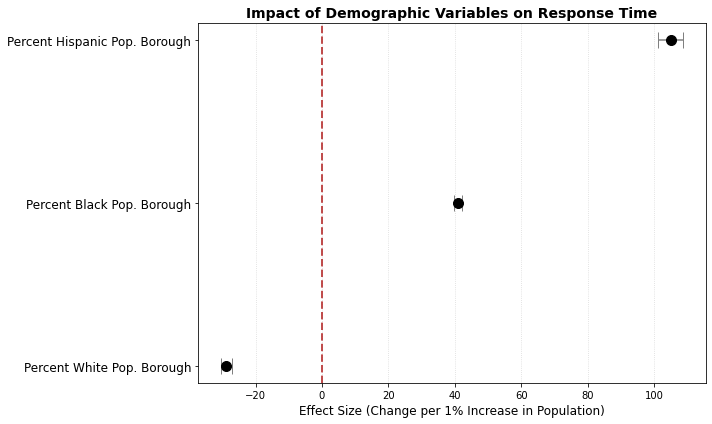

In [75]:
params = model3_borough.params
conf = model3_borough.conf_int()

plot_df = pd.DataFrame({
    'Variable': params.index,
    'Coefficient': params.values,
    'Lower': conf[0].values,
    'Upper': conf[1].values
})


target_vars = ['pct_white', 'pct_black', 'pct_hispanic']
filtered_df = plot_df[plot_df['Variable'].str.contains('|'.join(target_vars), case=False)].copy()

filtered_df['Clean_Label'] = filtered_df['Variable'].apply(clean_model_labels)


plt.figure(figsize=(10, 6))

filtered_df = filtered_df.sort_values('Coefficient')


y_pos = range(len(filtered_df))

plt.errorbar(filtered_df['Coefficient'], y_pos, 
             xerr=[filtered_df['Coefficient'] - filtered_df['Lower'], 
                   filtered_df['Upper'] - filtered_df['Coefficient']], 
             fmt='o', color='black', ecolor='gray', capsize=8, markersize=10)


plt.axvline(x=0, color='firebrick', linestyle='--', linewidth=2, alpha=0.8)

plt.yticks(y_pos, filtered_df['Clean_Label'], fontsize=12)

plt.xlabel('Effect Size (Change per 1% Increase in Population)', fontsize=12)
plt.title('Impact of Demographic Variables on Response Time', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/figures/demographic_impact_plot_borough.png", 
            dpi=300, 
            facecolor='white', 
            edgecolor='none', 
            transparent=False)
plt.show()

# Save Table Outputs

In [51]:
output_dir = "../outputs/tables"
os.makedirs(output_dir, exist_ok=True)

def save_model_table(model, filename, target_path=output_dir):
    table = pd.DataFrame({
        "coef": model.params,
        "std_err": model.bse,
        "t": model.tvalues,
        "p_value": model.pvalues
    })
    
    full_path = os.path.join(target_path, filename)
    table.to_csv(full_path)

save_model_table(control_model, "baseline_model.csv")
save_model_table(model3, "model_with_protected_variables.csv")
save_model_table(model3_borough, "model_with_protected_variables_borough.csv")